# NYC Airbnb 2019: General Dataset Information

This notebook begins an exploratory analysis of `AB_NYC_2019.csv`, a dataset of Airbnb listings across New York City's five boroughs. This section covers the dataset's size, structure, data quality, coverage, and basic descriptive statistics.

In [1]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# This works whether the notebook is launched from the project root or day6/.
data_path = Path("AB_NYC_2019.csv")
if not data_path.exists():
    data_path = Path("day6/AB_NYC_2019.csv")

df = pd.read_csv(data_path)
print(f"Loaded {data_path}: {df.shape[0]:,} rows and {df.shape[1]} columns")

Loaded AB_NYC_2019.csv: 48,895 rows and 16 columns


## 1. First look

In [2]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
overview = pd.DataFrame({
    "value": [
        f"{df.shape[0]:,}",
        df.shape[1],
        f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
        df["id"].nunique(),
        df["host_id"].nunique(),
        df["neighbourhood"].nunique(),
    ]
}, index=[
    "Rows (listings)", "Columns", "Memory usage",
    "Unique listing IDs", "Unique hosts", "Neighbourhoods"
])
overview

,value
Rows (listings),"48,895"
Columns,16
Memory usage,9.94 MB
Unique listing IDs,48895
Unique hosts,37457
Neighbourhoods,221


## 2. Columns and data types

The dataset contains identifiers and names, geographic fields, room and price information, review activity, host portfolio size, and annual availability.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
column_guide = pd.DataFrame({
    "column": df.columns,
    "meaning": [
        "Unique listing identifier",
        "Listing title",
        "Unique host identifier",
        "Host's displayed name",
        "NYC borough",
        "Neighbourhood name",
        "Listing latitude",
        "Listing longitude",
        "Type of accommodation offered",
        "Nightly price in US dollars",
        "Minimum required stay in nights",
        "Total number of reviews",
        "Date of the latest review",
        "Average reviews per month",
        "Number of listings operated by the host",
        "Available days in the next 365 days",
    ],
    "dtype": df.dtypes.astype(str).values,
})
column_guide

,column,meaning,dtype
0,id,Unique listing identifier,int64
1,name,Listing title,str
2,host_id,Unique host identifier,int64
3,host_name,Host's displayed name,str
4,neighbourhood_group,NYC borough,str
5,neighbourhood,Neighbourhood name,str
6,latitude,Listing latitude,float64
7,longitude,Listing longitude,float64
8,room_type,Type of accommodation offered,str
9,price,Nightly price in US dollars,int64


## 3. Data quality

Missing-value percentages are calculated against all 48,895 rows. A uniqueness count helps distinguish identifiers from categorical and repeated fields.

In [6]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
    "unique_values": df.nunique(dropna=True),
})
quality

,dtype,missing_count,missing_pct,unique_values
id,int64,0,0.00,48895
name,str,16,0.03,47905
host_id,int64,0,0.00,37457
host_name,str,21,0.04,11452
neighbourhood_group,str,0,0.00,5
neighbourhood,str,0,0.00,221
latitude,float64,0,0.00,19048
longitude,float64,0,0.00,14718
room_type,str,0,0.00,3
price,int64,0,0.00,674


In [7]:
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate listing IDs: {df['id'].duplicated().sum():,}")
print(f"Listings with a zero price: {(df['price'] == 0).sum():,}")

Exact duplicate rows: 0
Duplicate listing IDs: 0
Listings with a zero price: 11


`last_review` and `reviews_per_month` are missing together for listings with no recorded reviews. These are meaningful missing values rather than automatically being data-entry errors. The few missing listing and host names can be handled later if those text fields are needed.

## 4. Geographic and room-type coverage

In [8]:
borough_summary = (
    df["neighbourhood_group"]
    .value_counts()
    .rename_axis("borough")
    .to_frame("listings")
)
borough_summary["share_pct"] = borough_summary["listings"].div(len(df)).mul(100)
borough_summary

,listings,share_pct
borough,,
Manhattan,21661,44.30
Brooklyn,20104,41.12
Queens,5666,11.59
Bronx,1091,2.23
Staten Island,373,0.76


In [9]:
room_summary = (
    df["room_type"]
    .value_counts()
    .rename_axis("room_type")
    .to_frame("listings")
)
room_summary["share_pct"] = room_summary["listings"].div(len(df)).mul(100)
room_summary

,listings,share_pct
room_type,,
Entire home/apt,25409,51.97
Private room,22326,45.66
Shared room,1160,2.37


## 5. Numeric summary and review period

In [10]:
numeric_columns = [
    "price", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count",
    "availability_365",
]
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
price,"48,895.00",152.72,240.15,0.00,69.00,106.00,175.00,"10,000.00"
minimum_nights,"48,895.00",7.03,20.51,1.00,1.00,3.00,5.00,"1,250.00"
number_of_reviews,"48,895.00",23.27,44.55,0.00,1.00,5.00,24.00,629.00
reviews_per_month,"38,843.00",1.37,1.68,0.01,0.19,0.72,2.02,58.50
calculated_host_listings_count,"48,895.00",7.14,32.95,1.00,1.00,1.00,2.00,327.00
availability_365,"48,895.00",112.78,131.62,0.00,0.00,45.00,227.00,365.00


In [11]:
review_dates = pd.to_datetime(df["last_review"], errors="coerce")
pd.DataFrame({
    "value": [
        review_dates.min().date(),
        review_dates.max().date(),
        review_dates.notna().sum(),
    ]
}, index=["Earliest recorded review", "Latest recorded review", "Listings with a review date"])

,value
Earliest recorded review,2011-03-28
Latest recorded review,2019-07-08
Listings with a review date,38843


## Initial findings

- The dataset contains **48,895 listings and 16 columns**, with **48,895 unique listing IDs** and no exact duplicate rows.
- It covers **37,457 hosts**, **221 neighbourhoods**, and all **5 NYC boroughs**.
- Manhattan (44.3%) and Brooklyn (41.1%) together account for about **85.4%** of listings.
- Entire homes/apartments are the largest room category (52.0%), followed by private rooms (45.7%) and shared rooms (2.4%).
- The median nightly price is **$106**, while the mean is **$152.72** and the maximum is **$10,000**. This gap signals a strongly right-skewed price distribution and likely outliers.
- There are **11 zero-price listings**, which should be investigated or excluded from price-focused analysis.
- `last_review` and `reviews_per_month` each have **10,052 missing values (20.56%)**; these correspond to listings without recorded reviews.
- Recorded review dates range from **2011-03-28 to 2019-07-08**.

These checks establish the dataset's scope and flag the cleaning decisions needed before deeper analysis.

## 6. Focus on the `price` column

For prices, the mean and standard deviation are sensitive to extreme values, while the median and interquartile range (IQR) are robust. Looking at both sets of measures reveals the shape of the distribution.

In [12]:
price = df["price"]
q1, median, q3 = price.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1

price_statistics = pd.DataFrame({
    "statistic": [
        "Mean", "Median", "Standard deviation", "Minimum",
        "Q1 (25th percentile)", "Q2 (50th percentile)",
        "Q3 (75th percentile)", "Maximum", "IQR", "Range",
    ],
    "price_usd": [
        price.mean(), median, price.std(), price.min(),
        q1, median, q3, price.max(), iqr, price.max() - price.min(),
    ],
})
price_statistics

,statistic,price_usd
0,Mean,152.72
1,Median,106.00
2,Standard deviation,240.15
3,Minimum,0.00
4,Q1 (25th percentile),69.00
5,Q2 (50th percentile),106.00
6,Q3 (75th percentile),175.00
7,Maximum,"10,000.00"
8,IQR,106.00
9,Range,"10,000.00"


In [13]:
mean_median_gap = price.mean() - median
upper_fence = q3 + 1.5 * iqr
above_upper_fence = (price > upper_fence).sum()

shape_diagnostics = pd.DataFrame({
    "value": [
        mean_median_gap,
        mean_median_gap / median * 100,
        price.skew(),
        price.std() / price.mean() * 100,
        upper_fence,
        above_upper_fence,
        above_upper_fence / len(price) * 100,
    ]
}, index=[
    "Mean minus median (USD)",
    "Mean-median gap as % of median",
    "Skewness",
    "Coefficient of variation (%)",
    "Tukey upper fence (USD)",
    "Listings above upper fence",
    "Listings above upper fence (%)",
])
shape_diagnostics

,value
Mean minus median (USD),46.72
Mean-median gap as % of median,44.08
Skewness,19.12
Coefficient of variation (%),157.25
Tukey upper fence (USD),334.00
Listings above upper fence,"2,972.00"
Listings above upper fence (%),6.08


/tmp/ipykernel_140211/1958113579.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(price, vert=False, widths=0.6)
/tmp/ipykernel_140211/1958113579.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(price, vert=False, widths=0.6, showfliers=False)


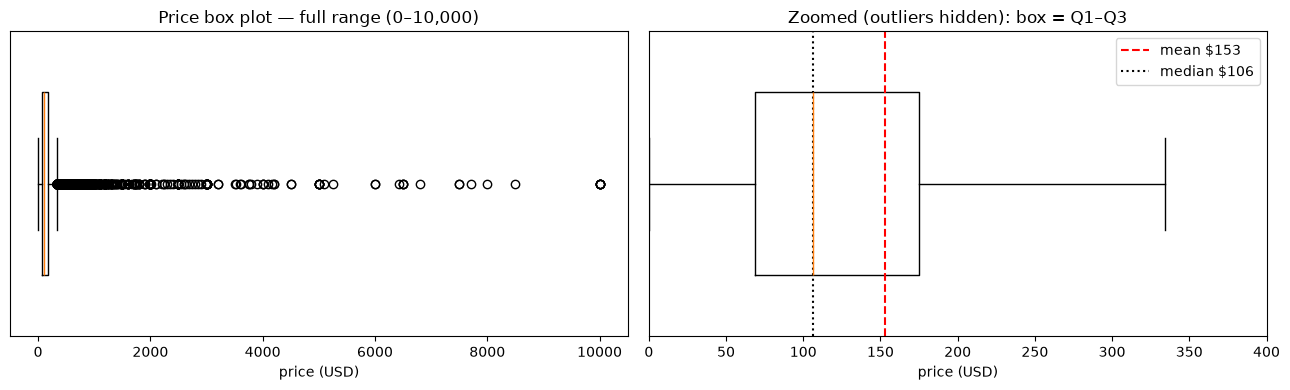

In [14]:
import matplotlib.pyplot as plt

price = df["price"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full range: the long tail of outliers dominates and hides the box entirely.
axes[0].boxplot(price, vert=False, widths=0.6)
axes[0].set_title("Price box plot — full range (0–10,000)")
axes[0].set_xlabel("price (USD)")
axes[0].set_yticks([])

# Zoomed with outliers hidden, so the quartile box becomes readable.
axes[1].boxplot(price, vert=False, widths=0.6, showfliers=False)
axes[1].axvline(price.mean(), color="red", linestyle="--", label=f"mean ${price.mean():.0f}")
axes[1].axvline(price.median(), color="black", linestyle=":", label=f"median ${price.median():.0f}")
axes[1].set_xlim(0, 400)
axes[1].set_title("Zoomed (outliers hidden): box = Q1–Q3")
axes[1].set_xlabel("price (USD)")
axes[1].set_yticks([])
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

- **The mean and median diverge substantially.** The mean is **$152.72**, whereas the median is **$106.00**: a gap of **$46.72**, or **44.1% of the median**. Expensive listings pull the mean upward, so the distribution is positively (right) skewed. The skewness value of **19.12** confirms that the skew is extreme.
- **The overall spread is very large.** The standard deviation is **$240.15**, which is greater than both the mean and the median. The coefficient of variation is about **157.3%**. This means prices are highly heterogeneous, although the standard deviation is inflated by the long upper tail and should not be read as the price of a typical listing.
- **The quartiles give a more stable picture.** Q1 is **$69**, the median is **$106**, and Q3 is **$175**. Thus, the middle 50% of listings cost between **$69 and $175**, an IQR of **$106**.
- The full range is **$0–$10,000**, much wider than the middle 50%. Using the conventional Tukey rule, prices above **$334** are upper-tail outliers; **2,972 listings (6.08%)** exceed this threshold. These observations are not automatically errors—they may represent luxury or unusually large properties—but they strongly affect the mean and standard deviation.

**Conclusion:** the median and IQR describe a typical NYC Airbnb listing better than the mean and standard deviation. For later price comparisons, it will be useful to inspect zero prices, segment listings by borough and room type, and consider a log scale or robust statistics.

## 7. Pearson correlations with `price`

All selected variables are numeric, so Pearson's correlation coefficient can be calculated directly. Each test evaluates the null hypothesis that the population **linear** correlation between `price` and the comparison variable is zero.

In [15]:
from scipy.stats import pearsonr

correlation_variables = [
    "number_of_reviews", "latitude", "longitude",
    "minimum_nights", "availability_365",
]

correlation_rows = []
for variable in correlation_variables:
    pair = df[["price", variable]].dropna()
    r_value, p_value = pearsonr(pair["price"], pair[variable])
    correlation_rows.append({
        "variable": variable,
        "n": len(pair),
        "Pearson_r": r_value,
        "p_value": p_value,
        "r_squared": r_value ** 2,
        "variance_associated_pct": r_value ** 2 * 100,
    })

correlation_results = pd.DataFrame(correlation_rows).set_index("variable")

# Keep these values for the price/reviews sensitivity check below.
correlation_data = df[["price", "number_of_reviews"]].dropna()
r = correlation_results.loc["number_of_reviews", "Pearson_r"]
p_value = correlation_results.loc["number_of_reviews", "p_value"]

correlation_results.style.format({
    "Pearson_r": "{:.4f}",
    "p_value": "{:.2e}",
    "r_squared": "{:.4f}",
    "variance_associated_pct": "{:.2f}",
})

,n,Pearson_r,p_value,r_squared,variance_associated_pct
variable,,,,,
number_of_reviews,48895,-0.0480,2.69e-26,0.0023,0.23
latitude,48895,0.0339,6.07e-14,0.0012,0.12
longitude,48895,-0.1500,5.10e-244,0.0225,2.25
minimum_nights,48895,0.0428,2.85e-21,0.0018,0.18
availability_365,48895,0.0818,2.06e-73,0.0067,0.67


In [16]:
# Sensitivity check: remove zero prices and upper-tail price outliers.
price_upper_fence = q3 + 1.5 * iqr
typical_prices = df[df["price"].between(0, price_upper_fence, inclusive="right")]
r_filtered, p_filtered = pearsonr(
    typical_prices["price"],
    typical_prices["number_of_reviews"],
)

pd.DataFrame({
    "sample": ["All listings", f"$0 < price <= ${price_upper_fence:.0f}"],
    "n": [len(correlation_data), len(typical_prices)],
    "Pearson_r": [r, r_filtered],
    "p_value": [p_value, p_filtered],
}).style.format({"Pearson_r": "{:.4f}", "p_value": "{:.2e}"})

,sample,n,Pearson_r,p_value
0,All listings,48895,-0.0480,2.69e-26
1,$0 < price <= $334,45912,-0.0276,3.29e-09


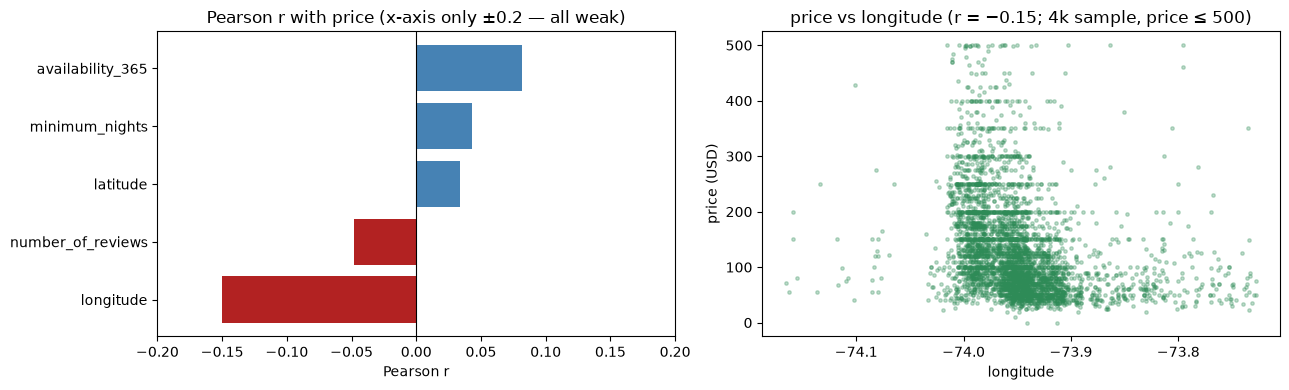

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# How strong is each linear relationship with price? Note the deliberately narrow x-axis.
r_sorted = correlation_results["Pearson_r"].sort_values()
bar_colors = ["firebrick" if value < 0 else "steelblue" for value in r_sorted]
axes[0].barh(r_sorted.index, r_sorted.values, color=bar_colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlim(-0.2, 0.2)
axes[0].set_title("Pearson r with price (x-axis only ±0.2 — all weak)")
axes[0].set_xlabel("Pearson r")

# The strongest correlate, longitude, still shows no visible trend.
sample = df.sample(4000, random_state=0)
sample = sample[sample["price"] <= 500]
axes[1].scatter(sample["longitude"], sample["price"], s=6, alpha=0.3, color="seagreen")
axes[1].set_title("price vs longitude (r = −0.15; 4k sample, price ≤ 500)")
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("price (USD)")

plt.tight_layout()
plt.show()

### Verdict

- **Number of reviews:** $r = -0.0480$—a negligible negative association. Its $r^2$ is only **0.0023**, corresponding to about **0.23%** of variance.
- **Latitude:** $r = 0.0339$—a negligible positive association (**0.12%** associated variance). Latitude alone says almost nothing about price.
- **Longitude:** $r = -0.1500$—the largest coefficient here, but still only a **weak negative** association (**2.25%** associated variance). Longitude partly reflects NYC's west–east geography and borough locations, so it may act as a rough location proxy.
- **Minimum nights:** $r = 0.0428$—a negligible positive association (**0.18%** associated variance).
- **Availability:** $r = 0.0818$—a negligible-to-very-weak positive association (**0.67%** associated variance).
- **Coincidence or detectable association?** Every p-value is below 0.05, so the coefficients are statistically distinguishable from zero under Pearson's assumptions. Nevertheless, with **48,895 observations**, tiny effects become significant. None of these variables has a strong linear relationship with price; longitude is the most noticeable but remains weak.
- **Price/reviews outlier check:** after excluding zero prices and prices above the $334 Tukey fence, $r$ changes from **−0.0480** to **−0.0276**. The practical conclusion remains the same.

**Correlation is not causation.** These results do not show that changing reviews, coordinates, minimum-stay rules, or availability causes the price to change. Borough, room type, property characteristics, listing age, and other confounders may affect both price and the selected variables.

## 8. Pearson correlations calculated separately by borough

The citywide coefficients can conceal subgroup patterns. Here, the correlation between `price` and each selected numeric variable is recalculated independently within every `neighbourhood_group`.

In [18]:
group_correlation_variables = [
    "latitude", "longitude", "minimum_nights",
    "number_of_reviews", "availability_365",
]

group_correlation_rows = []
for borough, group_data in df.groupby("neighbourhood_group"):
    for variable in group_correlation_variables:
        pair = group_data[["price", variable]].dropna()
        r_value, p_value = pearsonr(pair["price"], pair[variable])
        group_correlation_rows.append({
            "neighbourhood_group": borough,
            "variable": variable,
            "n": len(pair),
            "Pearson_r": r_value,
            "p_value": p_value,
            "r_squared_pct": r_value ** 2 * 100,
        })

group_correlation_long = pd.DataFrame(group_correlation_rows)
correlation_by_group = group_correlation_long.pivot(
    index="neighbourhood_group",
    columns="variable",
    values="Pearson_r",
).reindex(columns=group_correlation_variables)

correlation_by_group.style.format("{:.3f}").background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
)

variable,latitude,longitude,minimum_nights,number_of_reviews,availability_365
neighbourhood_group,,,,,
Bronx,0.045,0.048,-0.031,-0.061,0.068
Brooklyn,0.054,-0.099,0.016,-0.010,0.061
Manhattan,-0.146,-0.164,0.029,-0.061,0.118
Queens,-0.010,-0.009,0.150,-0.041,0.039
Staten Island,-0.008,-0.018,-0.004,-0.081,0.038


In [19]:
# Supporting information: group sizes and p-values for each coefficient.
group_sizes = (
    df.groupby("neighbourhood_group")
    .size()
    .rename("n")
    .to_frame()
)

p_values_by_group = group_correlation_long.pivot(
    index="neighbourhood_group",
    columns="variable",
    values="p_value",
).reindex(columns=group_correlation_variables)

display(group_sizes)
display(p_values_by_group.style.format("{:.2e}"))

,n
neighbourhood_group,
Bronx,1091
Brooklyn,20104
Manhattan,21661
Queens,5666
Staten Island,373


variable,latitude,longitude,minimum_nights,number_of_reviews,availability_365
neighbourhood_group,,,,,
Bronx,1.33e-01,1.16e-01,3.01e-01,4.29e-02,2.43e-02
Brooklyn,2.77e-14,6.06e-45,2.11e-02,1.56e-01,2.63e-18
Manhattan,7.79e-104,4.71e-130,2.41e-05,2.89e-19,4.74e-68
Queens,4.68e-01,5.09e-01,5.00e-30,1.99e-03,3.13e-03
Staten Island,8.83e-01,7.24e-01,9.40e-01,1.16e-01,4.66e-01


### Group-level verdict

- **No strong linear correlation appears in any borough.** All 25 coefficients have $|r| < 0.17$, so splitting the data does not overturn the citywide conclusion.
- **Bronx:** the largest coefficient is for availability ($r = 0.068$); all relationships are negligible.
- **Brooklyn:** longitude has the largest coefficient ($r = -0.099$), still negligible-to-very-weak.
- **Manhattan:** longitude ($r = -0.164$), latitude ($r = -0.146$), and availability ($r = 0.118$) show the most visible patterns, but they remain weak. Longitude explains only about **2.68%** of price variance within Manhattan.
- **Queens:** minimum nights has a weak positive association with price ($r = 0.150$), accounting for about **2.26%** of variance. The other coefficients are negligible.
- **Staten Island:** the largest coefficient is reviews ($r = -0.081$), but none of its five p-values is below 0.05. Its smaller sample ($n = 373$) also gives less precise estimates.
- Several tiny coefficients are statistically significant in the larger boroughs because Manhattan and Brooklyn contain tens of thousands of listings. Statistical significance should not be mistaken for a strong or useful relationship.

**Correlation is still not causation.** Even within boroughs, these bivariate coefficients do not isolate causal effects. Room type, exact neighbourhood, property characteristics, host behavior, and price outliers can influence the observed relationships.

## 9. Pearson correlations calculated separately by room type

As a final check, the correlations between `price` and the same five numeric variables are recalculated independently for `Entire home/apt`, `Private room`, and `Shared room` listings.

In [20]:
room_correlation_rows = []
for room_type, group_data in df.groupby("room_type"):
    for variable in group_correlation_variables:
        pair = group_data[["price", variable]].dropna()
        r_value, p_value = pearsonr(pair["price"], pair[variable])
        room_correlation_rows.append({
            "room_type": room_type,
            "variable": variable,
            "n": len(pair),
            "Pearson_r": r_value,
            "p_value": p_value,
            "r_squared_pct": r_value ** 2 * 100,
        })

room_correlation_long = pd.DataFrame(room_correlation_rows)
correlation_by_room_type = room_correlation_long.pivot(
    index="room_type",
    columns="variable",
    values="Pearson_r",
).reindex(columns=group_correlation_variables)

correlation_by_room_type.style.format("{:.3f}").background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
)

variable,latitude,longitude,minimum_nights,number_of_reviews,availability_365
room_type,,,,,
Entire home/apt,0.041,-0.121,0.013,-0.061,0.113
Private room,0.033,-0.098,0.061,-0.029,0.056
Shared room,0.121,-0.102,-0.017,-0.064,-0.097


In [21]:
# Supporting information: room-type sample sizes and p-values.
room_type_sizes = (
    df.groupby("room_type")
    .size()
    .rename("n")
    .to_frame()
)

p_values_by_room_type = room_correlation_long.pivot(
    index="room_type",
    columns="variable",
    values="p_value",
).reindex(columns=group_correlation_variables)

display(room_type_sizes)
display(p_values_by_room_type.style.format("{:.2e}"))

,n
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


variable,latitude,longitude,minimum_nights,number_of_reviews,availability_365
room_type,,,,,
Entire home/apt,9.49e-11,9.49e-84,3.41e-02,1.13e-22,1.17e-72
Private room,5.83e-07,6.12e-49,4.20e-20,1.89e-05,7.15e-17
Shared room,3.63e-05,5.26e-04,5.59e-01,2.94e-02,9.96e-04


### Room-type verdict

- **No strong linear correlation appears within any room type.** All 15 coefficients have $|r| < 0.122$, reinforcing the overall and borough-level conclusions.
- **Entire home/apt:** longitude has the largest coefficient ($r = -0.121$), followed by availability ($r = 0.113$). Each explains less than **1.5%** of price variance.
- **Private room:** longitude is again the largest coefficient ($r = -0.098$); all other relationships are negligible.
- **Shared room:** latitude ($r = 0.121$), longitude ($r = -0.102$), and availability ($r = -0.097$) are the largest coefficients, but remain weak. The availability direction is negative here, unlike the positive coefficients for the other two room types.
- Minimum nights for shared rooms is the only tested relationship with a clearly non-significant p-value ($p = 0.559$). Most other tiny coefficients are statistically significant because of their sample sizes, particularly for entire homes and private rooms.
- The largest $r^2$ is only about **1.47%**, so none of these variables individually explains much of the variation in price within a room type.

**Final conclusion:** price has no strong bivariate linear correlation with latitude, longitude, minimum nights, review count, or availability—whether the data are analyzed overall, by borough, or by room type. **Correlation does not imply causation**, and a multivariable model would be needed to study their combined predictive contribution while controlling for confounders.

In [22]:
# A small, reproducible slice: the first six listings.
manual_sample = df.loc[:5, ["id", "price", "number_of_reviews"]].copy()
x = manual_sample["price"]
y = manual_sample["number_of_reviews"]

# Build every component of Pearson's formula explicitly.
manual_sample["x_minus_xbar"] = x - x.mean()
manual_sample["y_minus_ybar"] = y - y.mean()
manual_sample["cross_product"] = (
    manual_sample["x_minus_xbar"] * manual_sample["y_minus_ybar"]
)
manual_sample["x_deviation_squared"] = manual_sample["x_minus_xbar"] ** 2
manual_sample["y_deviation_squared"] = manual_sample["y_minus_ybar"] ** 2

manual_sample.round(3)

,id,price,number_of_reviews,x_minus_xbar,y_minus_ybar,cross_product,x_deviation_squared,y_deviation_squared
0,2539,149,9,0.17,-58.83,-9.81,0.03,"3,461.36"
1,2595,225,45,76.17,-22.83,"-1,739.14","5,801.36",521.36
2,3647,150,0,1.17,-67.83,-79.14,1.36,"4,601.36"
3,3831,89,270,-59.83,202.17,"-12,096.31","3,580.03","40,871.36"
4,5022,80,9,-68.83,-58.83,"4,049.69","4,738.03","3,461.36"
5,5099,200,74,51.17,6.17,315.53,"2,618.03",38.03


In [23]:
numerator = manual_sample["cross_product"].sum()
sum_x_squared = manual_sample["x_deviation_squared"].sum()
sum_y_squared = manual_sample["y_deviation_squared"].sum()
denominator = (sum_x_squared * sum_y_squared) ** 0.5
manual_r = numerator / denominator

# Only after the manual reconstruction, compare it with the library result.
library_r, library_p = pearsonr(x, y)

manual_check = pd.DataFrame({
    "value": [
        x.mean(), y.mean(), numerator, sum_x_squared, sum_y_squared,
        denominator, manual_r, library_r, abs(manual_r - library_r), library_p,
    ]
}, index=[
    "Mean price (x̄)",
    "Mean review count (ȳ)",
    "Numerator: Σ[(x-x̄)(y-ȳ)]",
    "Σ(x-x̄)²",
    "Σ(y-ȳ)²",
    "Denominator",
    "Pearson r — manual formula",
    "Pearson r — scipy.stats",
    "Absolute difference",
    "Small-sample p-value",
])
manual_check

,value
Mean price (x̄),148.83
Mean review count (ȳ),67.83
Numerator: Σ[(x-x̄)(y-ȳ)],"-9,559.17"
Σ(x-x̄)²,"16,738.83"
Σ(y-ȳ)²,"52,954.83"
Denominator,"29,772.51"
Pearson r — manual formula,-0.32
Pearson r — scipy.stats,-0.32
Absolute difference,0.00
Small-sample p-value,0.53


### Manual-check verdict

The explicit formula gives **$r = -0.3210736302$**, and `scipy.stats.pearsonr` gives the same value to floating-point precision (absolute difference below $10^{-15}$). The machine's Pearson calculation is therefore confirmed on this inspectable six-row slice.

The six-row result itself is **not statistically significant** ($p = 0.535$) and is more negative than the full-data result ($r = -0.048$). This is not a contradiction: six observations are too few to estimate the dataset-wide relationship reliably. It demonstrates why every statistic must be accompanied by its row count and why a convenient small slice should verify the arithmetic—not replace the full sample.

**Tasks 1, 2, and 3 are now complete.** The defensible finding is: price is highly right-skewed, its typical value is better represented by the median than the mean, and its linear relationship with review count is statistically detectable in the full dataset but practically negligible. Correlation does not establish causation.

## 10. Shape of the `price` distribution (Task 4)

Summary statistics describe location and spread but hide *shape*. Here the price distribution is plotted three ways — full range, zoomed to the bulk, and on a log scale — and tested for normality, looking for skew, multiple peaks, and outliers the mean conceals.

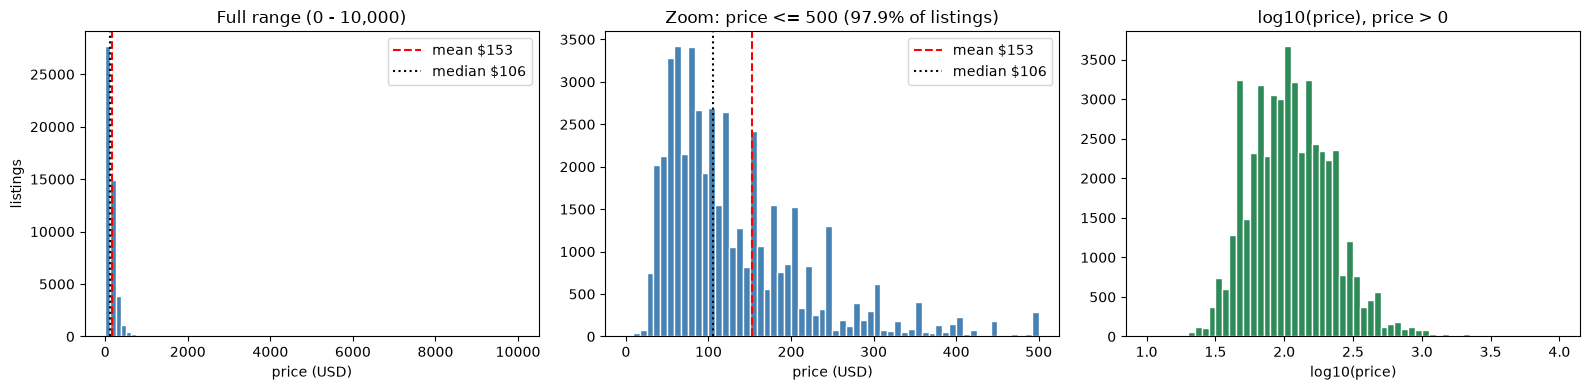

In [24]:
import numpy as np
import matplotlib.pyplot as plt

price = df["price"]
mean, median = price.mean(), price.median()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full range: the long tail makes the bulk invisible.
axes[0].hist(price, bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Full range (0 - 10,000)")
axes[0].set_xlabel("price (USD)")
axes[0].set_ylabel("listings")

# Zoomed to the bulk of the data.
zoom = price[price <= 500]
axes[1].hist(zoom, bins=60, color="steelblue", edgecolor="white")
axes[1].set_title(f"Zoom: price <= 500 ({len(zoom) / len(price) * 100:.1f}% of listings)")
axes[1].set_xlabel("price (USD)")

# log10 scale: tames the skew and reveals the shape.
axes[2].hist(np.log10(price[price > 0]), bins=60, color="seagreen", edgecolor="white")
axes[2].set_title("log10(price), price > 0")
axes[2].set_xlabel("log10(price)")

for ax in (axes[0], axes[1]):
    ax.axvline(mean, color="red", linestyle="--", label=f"mean ${mean:.0f}")
    ax.axvline(median, color="black", linestyle=":", label=f"median ${median:.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import shapiro

price = df["price"]
log_price = np.log10(price[price > 0])

# Shapiro-Wilk needs n <= 5000, so test a random sample.
sw_stat, sw_p = shapiro(price.sample(5000, random_state=0))

within_1sd = price.between(price.mean() - price.std(), price.mean() + price.std()).mean() * 100

shape_table = pd.DataFrame({
    "value": [
        price.skew(),
        log_price.skew(),
        price.kurt(),
        sw_stat,
        sw_p,
        within_1sd,
        68.3,
    ]
}, index=[
    "Skewness (raw price)",
    "Skewness (log10 price)",
    "Excess kurtosis (raw price)",
    "Shapiro-Wilk W (n=5000 sample)",
    "Shapiro-Wilk p-value",
    "% of listings within mean +/- 1 SD",
    "% expected within +/- 1 SD if normal",
])

print("Most frequent prices (round-number spikes):", price.value_counts().head(8).to_dict())
shape_table.style.format({"value": "{:.4g}"})

Most frequent prices (round-number spikes): {100: 2051, 150: 2047, 50: 1534, 60: 1458, 200: 1401, 75: 1370, 80: 1272, 65: 1190}


,value
Skewness (raw price),19.12
Skewness (log10 price),0.6082
Excess kurtosis (raw price),585.7
Shapiro-Wilk W (n=5000 sample),0.268
Shapiro-Wilk p-value,1.311e-88
% of listings within mean +/- 1 SD,95.63
% expected within +/- 1 SD if normal,68.3


### Interpretation of the shape

- **The distribution is not normal — not even close.** Raw skewness is **19.1** and excess kurtosis is **≈586** (a normal distribution has 0 for both). The Shapiro–Wilk test on a 5,000-row sample returns p ≈ 10⁻⁸⁸, decisively rejecting normality. (With this much data the test would reject even mild departures, so the skew and the histogram are the substantive evidence, not the p-value alone.)
- **It is a single sharp peak with a very long right tail, not two humps.** On the raw scale almost everything is crushed into the left bins while a thin tail stretches to \$10,000. A log₁₀ transform pulls it close to symmetric (skew falls from 19.1 to **0.61**), confirming one mode rather than genuine bimodality. The apparent "spikes" in the zoomed histogram are **round-number pricing** — the most common prices are \$100, \$150, \$50, \$60, \$200, \$75 — not a second population.
- **The "±1 SD ≈ 68%" intuition breaks.** **95.6%** of listings fall within mean ± 1 SD, versus the **68.3%** a normal distribution predicts. The mean+SD ruler is distorted by the tail.
- **Outliers invisible in the mean.** The mean (\$152.72) sits at roughly the **70th percentile** of prices, above about 70% of all listings — already a hint the tail is doing the talking. The extreme listings (up to \$10,000) never show up in a single summary number; only the distribution reveals them.

## 11. z-score outliers (Task 5)

Standardizing the column expresses each price as the number of standard deviations from the mean. Points with `|z| > 2` (and the stricter `|z| > 3`) are conventional anomaly candidates. Because price is heavily skewed, the standard z-score is also compared against a robust median/MAD version and the Tukey IQR rule.

In [26]:
price = df["price"]

# Standard z-score: distance from the mean in standard deviations.
mean, std = price.mean(), price.std()
z = (price - mean) / std

# Robust (modified) z-score: uses the median and MAD, which outliers barely move.
median = price.median()
mad = (price - median).abs().median()
modified_z = 0.6745 * (price - median) / mad

# Tukey IQR upper fence for comparison.
q1, q3 = price.quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)

zscore_table = pd.DataFrame({
    "rule": [
        "Standard z  (|z| > 2)",
        "Standard z  (|z| > 3)",
        "Modified z / MAD  (|z| > 3.5)",
        "Tukey IQR upper fence",
    ],
    "flagged": [
        int((z.abs() > 2).sum()),
        int((z.abs() > 3).sum()),
        int((modified_z.abs() > 3.5).sum()),
        int((price > upper_fence).sum()),
    ],
})
zscore_table["flagged_pct"] = zscore_table["flagged"] / len(price) * 100

print(f"Most extreme standard z-scores: min = {z.min():.2f}, max = {z.max():.2f}")
print(f"Standard z > 2 means price > ${mean + 2 * std:,.0f};  z > 3 means price > ${mean + 3 * std:,.0f}")
zscore_table.style.format({"flagged": "{:,}", "flagged_pct": "{:.2f}"})

Most extreme standard z-scores: min = -0.64, max = 41.00
Standard z > 2 means price > $633;  z > 3 means price > $873


,rule,flagged,flagged_pct
0,Standard z (|z| > 2),767,1.57
1,Standard z (|z| > 3),388,0.79
2,Modified z / MAD (|z| > 3.5),"2,916",5.96
3,Tukey IQR upper fence,"2,972",6.08


In [27]:
# The five most extreme high-price listings by standard z-score.
z_scores = (df["price"] - df["price"].mean()) / df["price"].std()
top_outliers = (
    df.assign(z_score=z_scores)
    .nlargest(5, "z_score")[
        ["id", "neighbourhood_group", "room_type", "price", "z_score"]
    ]
)
display(top_outliers.style.format({"z_score": "{:.2f}"}))

# Manual check on the single most extreme listing.
extreme = df.loc[df["price"].idxmax()]
manual_z = (extreme["price"] - df["price"].mean()) / df["price"].std()
print(
    f"Listing {int(extreme['id'])}: z = "
    f"({extreme['price']:,} - {df['price'].mean():.2f}) / {df['price'].std():.2f} = {manual_z:.2f}"
)

,id,neighbourhood_group,room_type,price,z_score
9151,7003697,Queens,Private room,10000,41.00
17692,13894339,Brooklyn,Entire home/apt,10000,41.00
29238,22436899,Manhattan,Entire home/apt,10000,41.00
6530,4737930,Manhattan,Entire home/apt,9999,41.00
12342,9528920,Manhattan,Private room,9999,41.00


Listing 7003697: z = (10,000 - 152.72) / 240.15 = 41.00


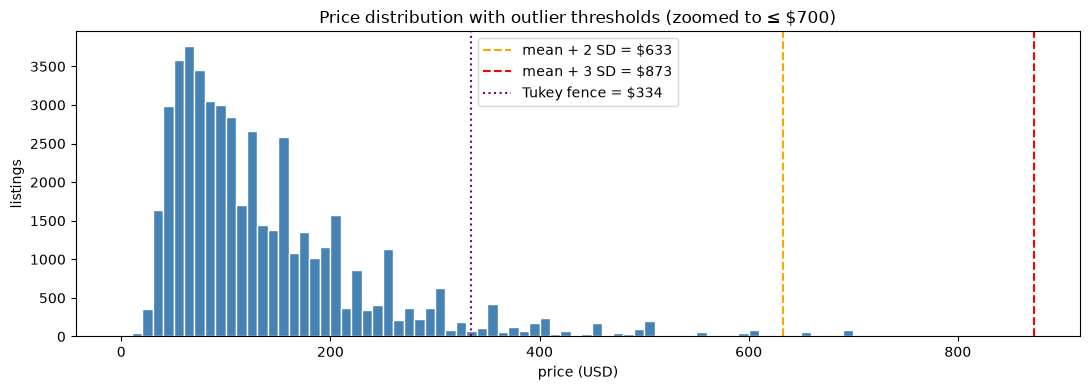

In [28]:
import matplotlib.pyplot as plt

price = df["price"]
mean, std = price.mean(), price.std()

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(price[price <= 700], bins=70, color="steelblue", edgecolor="white")
for k, color in [(2, "orange"), (3, "red")]:
    ax.axvline(mean + k * std, color=color, linestyle="--",
               label=f"mean + {k} SD = ${mean + k * std:.0f}")
ax.axvline(upper_fence, color="purple", linestyle=":",
           label=f"Tukey fence = ${upper_fence:.0f}")
ax.set_title("Price distribution with outlier thresholds (zoomed to ≤ $700)")
ax.set_xlabel("price (USD)")
ax.set_ylabel("listings")
ax.legend()
plt.tight_layout()
plt.show()

### Verdict: z-scores on a skewed column

- **The standard z-score flags only the upper tail.** The minimum z is just **−0.64** (price 0 sits barely below the mean), while the maximum is **+41.0**. Because price is bounded below by 0 and has a long right tail, *no* listing can have a large negative z. Every anomaly the method can find is an expensive one.
- **Counts.** `|z| > 2` flags **767** listings (1.57%) — those above ≈\$633; `|z| > 3` flags **388** (0.79%) — above ≈\$873. These are the headline anomaly candidates.
- **z-score under-flags here, because mean and SD are themselves contaminated.** The outliers inflate the standard deviation (\$240), which widens the ±2/±3 SD net and lets moderately expensive listings slip through. The robust **modified z-score** (built from the median and MAD, which outliers barely move) flags **2,916** listings at the |z|>3.5 cut — far more, and almost exactly the **2,972** the Tukey IQR rule found. On skewed data the robust rule and the IQR rule agree; the textbook z-score is the outlier.
- **Manual check.** For the \$10,000 listing: z = (10000 − 152.72) / 240.15 = **41.0**, matching the computed value. The arithmetic is confirmed on a single row.

**Takeaway:** `|z| > 3` is a reasonable shortlist of *extreme* high-price listings, but on a right-skewed column it is conservative and blind to the low end. Prefer the median/MAD or IQR rule for outlier screening.

## 12. The mean that lies (Task 6)

A single number called "the average" invites trust. This section shows three concrete ways the price mean misleads: (a) a mean computed over very few rows, (b) a mean dominated by one outlier, and (c) a mean built by naively averaging group means. Each is checked against the median or the raw values.

In [29]:
# Neighbourhoods with very few listings but a high mean price:
# candidates for a mean distorted by sample size and a single outlier.
neighbourhood_stats = df.groupby("neighbourhood")["price"].agg(
    n="size", mean="mean", median="median", max="max"
)
small_inflated = (
    neighbourhood_stats[neighbourhood_stats["n"] <= 12]
    .sort_values("mean", ascending=False)
    .head(6)
)
small_inflated

,n,mean,median,max
neighbourhood,,,,
Fort Wadsworth,1,800.00,800.00,800
Woodrow,1,700.00,700.00,700
Sea Gate,7,487.86,125.00,1485
Riverdale,11,442.09,150.00,2500
Prince's Bay,4,409.50,151.50,1250
Neponsit,3,274.67,274.00,350


In [30]:
# Three ways the price mean can mislead.

# 1. One outlier in a small group: Sea Gate (only 7 listings).
sea_gate = df.loc[df["neighbourhood"] == "Sea Gate", "price"].sort_values()
print("Sea Gate listings (n=7):", sea_gate.tolist())
print(f"  mean   = ${sea_gate.mean():.2f}")
print(f"  median = ${sea_gate.median():.2f}")
print(f"  mean after dropping the single ${sea_gate.max():,} listing = ${sea_gate.iloc[:-1].mean():.2f}")

# 2. Averaging averages: unweighted mean of borough means vs the true overall mean.
borough_mean = df.groupby("neighbourhood_group")["price"].mean()
print()
print(f"Unweighted average of the 5 borough means : ${borough_mean.mean():.2f}")
print(f"True listing-level overall mean           : ${df['price'].mean():.2f}")

# 3. At scale a single outlier barely moves the mean.
full_mean = df["price"].mean()
without_max = df.loc[df["price"] < df["price"].max(), "price"].mean()
print()
print(f"Overall mean, all rows               : ${full_mean:.2f}")
print(f"Overall mean, dropping all $10,000 rows: ${without_max:.2f}  (shift of only ${full_mean - without_max:.2f})")

Sea Gate listings (n=7): [71, 97, 99, 125, 223, 1315, 1485]
  mean   = $487.86
  median = $125.00
  mean after dropping the single $1,485 listing = $321.67

Unweighted average of the 5 borough means : $124.62
True listing-level overall mean           : $152.72

Overall mean, all rows               : $152.72
Overall mean, dropping all $10,000 rows: $152.12  (shift of only $0.60)


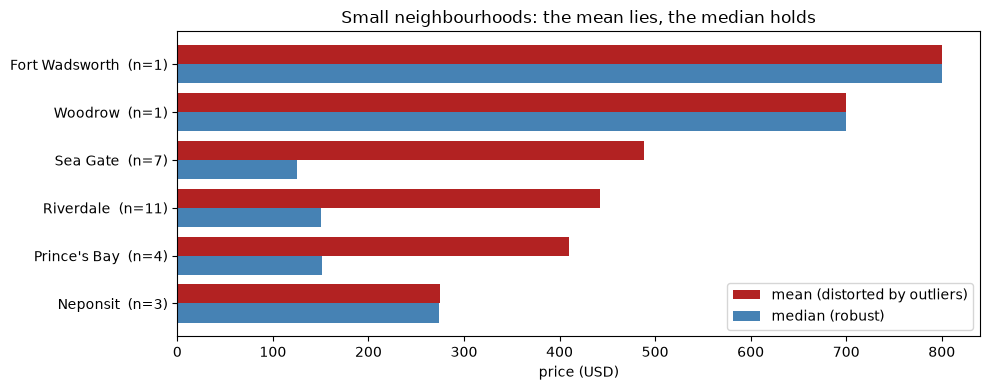

In [31]:
import matplotlib.pyplot as plt

plot_data = small_inflated.sort_values("mean")
positions = range(len(plot_data))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh([p + 0.2 for p in positions], plot_data["mean"], height=0.4,
        color="firebrick", label="mean (distorted by outliers)")
ax.barh([p - 0.2 for p in positions], plot_data["median"], height=0.4,
        color="steelblue", label="median (robust)")
ax.set_yticks(list(positions))
ax.set_yticklabels([f"{name}  (n={int(n)})"
                    for name, n in zip(plot_data.index, plot_data["n"])])
ax.set_xlabel("price (USD)")
ax.set_title("Small neighbourhoods: the mean lies, the median holds")
ax.legend()
plt.tight_layout()
plt.show()

### Verdict: when the mean lies

- **Small samples + one outlier.** Sea Gate has only **7 listings**. Five of them cost between \$71 and \$223, but two luxury listings (\$1,315 and \$1,485) drag the mean to **\$487.86** — almost **4×** the median of **\$125**. Removing just the single most expensive listing drops the mean to \$321.67. Reporting "the average Sea Gate listing costs \$488" would be a lie about a typical stay there. The same pattern holds for Riverdale (n=11, mean \$442 vs median \$150).
- **A mean is only as trustworthy as its row count.** Each value should travel with its `n`. A mean over 7 rows is a rumour; a median survives a few extreme values intact.
- **Averaging averages is not the overall average.** The unweighted mean of the five borough means is **\$124.62**, but the true listing-level mean is **\$152.72**. The gap exists because Manhattan (mean \$196.88) holds ~44% of all listings, while cheap Bronx (\$87.50) and Staten Island hold very few. Treating every borough as equally weighted silently down-weights Manhattan and understates the citywide figure.
- **At scale, a single outlier barely moves the mean — which is its own trap.** Dropping *all three* \$10,000 listings changes the citywide mean by only about \$0.60. The very same \$10,000 value that is invisible among 48,895 rows would single-handedly dominate a 7-row neighbourhood. Outlier sensitivity is a function of sample size, not just of the outlier.

**Manual verification.** Sea Gate's seven prices are `[71, 97, 99, 125, 223, 1315, 1485]`. By hand: sum = 3,415, ÷ 7 = **\$487.86** (matches the machine); the middle value is **\$125** (matches the median). Confirmed on an inspectable slice.

**Bottom line for the `price` column:** report the **median and IQR**, always with the row count, and never average pre-computed group means without weighting by group size.

## 13. Shift the sample (Task 7)

A statistic is only as honest as the rows behind it. Here a deliberately biased subset is taken — keeping only listings that *have* reviews, a filter that masquerades as routine cleaning — to watch how the price statistics move and to identify which listings silently disappear from the picture.

In [32]:
price = df["price"]

# A filter that looks like harmless cleaning: keep only "active" listings that have reviews.
active = df[df["number_of_reviews"] > 0]
dropped = df[df["number_of_reviews"] == 0]

sample_shift = pd.DataFrame({
    "full dataset": [len(df), price.mean(), price.median()],
    "reviewed only": [len(active), active["price"].mean(), active["price"].median()],
    "dropped (no reviews)": [len(dropped), dropped["price"].mean(), dropped["price"].median()],
}, index=["n", "mean price", "median price"])
display(sample_shift.style.format("{:,.2f}"))

# Who silently dropped out? Borough mix of the removed listings vs the full data.
who_dropped = pd.DataFrame({
    "full %": df["neighbourhood_group"].value_counts(normalize=True) * 100,
    "dropped %": dropped["neighbourhood_group"].value_counts(normalize=True) * 100,
})
who_dropped.style.format("{:.1f}")

,full dataset,reviewed only,dropped (no reviews)
n,"48,895.00","38,843.00","10,052.00"
mean price,152.72,142.32,192.92
median price,106.00,101.00,120.00


,full %,dropped %
neighbourhood_group,,
Manhattan,44.3,50.0
Brooklyn,41.1,36.4
Queens,11.6,10.9
Bronx,2.2,2.1
Staten Island,0.8,0.6


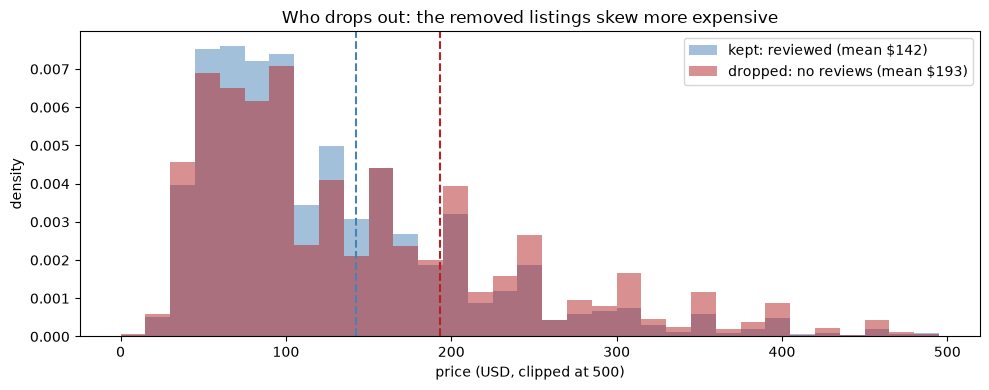

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 501, 15)
ax.hist(active["price"].clip(upper=500), bins=bins, density=True, alpha=0.5,
        color="steelblue", label=f"kept: reviewed (mean ${active['price'].mean():.0f})")
ax.hist(dropped["price"].clip(upper=500), bins=bins, density=True, alpha=0.5,
        color="firebrick", label=f"dropped: no reviews (mean ${dropped['price'].mean():.0f})")
ax.axvline(active["price"].mean(), color="steelblue", linestyle="--")
ax.axvline(dropped["price"].mean(), color="firebrick", linestyle="--")
ax.set_title("Who drops out: the removed listings skew more expensive")
ax.set_xlabel("price (USD, clipped at 500)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation: a filter that quietly biases price

- Keeping only listings "with at least one review" sounds like sensible cleaning — drop the dormant listings. It removes **10,052 listings (20.6%)** and pulls the mean price from **\$152.72 to \$142.32** and the median from \$106 to \$101.
- **Who silently dropped out?** The removed no-review listings are *more expensive*, not less: mean **\$192.92**, median \$120. They are disproportionately **Manhattan** (50.0% of the dropped set vs 44.3% of the full data). Newly listed, never-reviewed, high-priced Manhattan properties are exactly the segment this filter erases.
- The shift is modest in dollars (~\$10) but the **direction is the trap**: a filter advertised as "quality control" introduces a *downward* bias in the price estimate and under-represents Manhattan. Any reported "average price" must state which listings were included and which were quietly excluded.

## 14. Compare two groups with a t-test (Task 8)

Two-sample Welch t-tests compare mean `price` between groups. Two contrasts are run deliberately: one expected to be large (room type) and one expected to be modest (two boroughs). Alongside each p-value, **Cohen's d** measures the *size* of the difference, so significance and practical importance can be judged separately.

In [34]:
import numpy as np
from scipy.stats import ttest_ind


def cohens_d(a, b):
    """Standardized mean difference using the pooled standard deviation."""
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(
        ((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2)
    )
    return (a.mean() - b.mean()) / pooled_sd


comparisons = {
    # A difference that should be large.
    "Entire home/apt vs Private room": (
        df.loc[df["room_type"] == "Entire home/apt", "price"],
        df.loc[df["room_type"] == "Private room", "price"],
    ),
    # A difference that is real but modest.
    "Brooklyn vs Queens": (
        df.loc[df["neighbourhood_group"] == "Brooklyn", "price"],
        df.loc[df["neighbourhood_group"] == "Queens", "price"],
    ),
}

ttest_rows = []
for label, (group_a, group_b) in comparisons.items():
    # Welch's t-test does not assume equal variances.
    t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)
    ttest_rows.append({
        "comparison": label,
        "mean_A": group_a.mean(),
        "mean_B": group_b.mean(),
        "diff": group_a.mean() - group_b.mean(),
        "t": t_stat,
        "p_value": p_value,
        "cohens_d": cohens_d(group_a, group_b),
        "n": len(group_a) + len(group_b),
    })

ttest_results = pd.DataFrame(ttest_rows).set_index("comparison")
ttest_results.style.format({
    "mean_A": "${:.2f}", "mean_B": "${:.2f}", "diff": "${:.2f}",
    "t": "{:.1f}", "p_value": "{:.2e}", "cohens_d": "{:.3f}", "n": "{:,}",
})

,mean_A,mean_B,diff,t,p_value,cohens_d,n
comparison,,,,,,,
Entire home/apt vs Private room,$211.79,$89.78,$122.01,58.7,0.00e+00,0.521,"47,735"
Brooklyn vs Queens,$124.38,$99.52,$24.87,9.6,7.33e-22,0.136,"25,770"


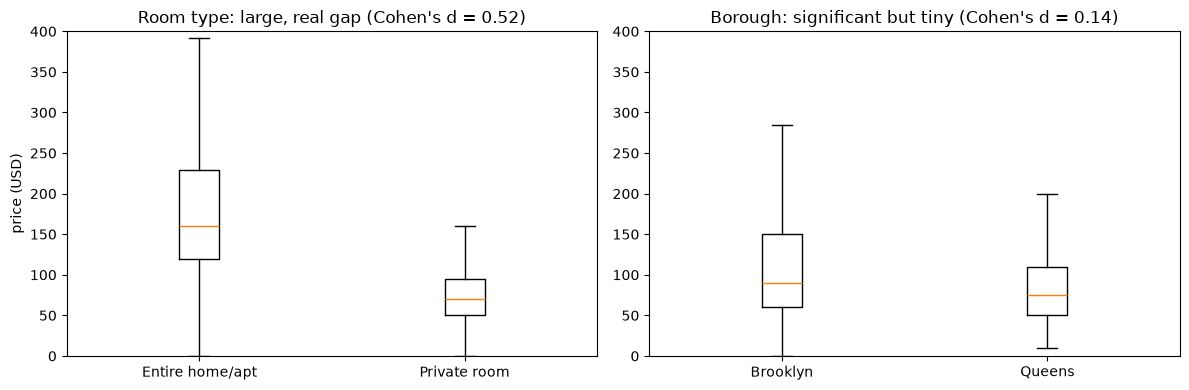

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Large, real gap.
room_groups = [
    df.loc[df["room_type"] == "Entire home/apt", "price"],
    df.loc[df["room_type"] == "Private room", "price"],
]
axes[0].boxplot(room_groups, showfliers=False)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Entire home/apt", "Private room"])
axes[0].set_ylim(0, 400)
axes[0].set_ylabel("price (USD)")
axes[0].set_title("Room type: large, real gap (Cohen's d = 0.52)")

# Significant but tiny gap.
boro_groups = [
    df.loc[df["neighbourhood_group"] == "Brooklyn", "price"],
    df.loc[df["neighbourhood_group"] == "Queens", "price"],
]
axes[1].boxplot(boro_groups, showfliers=False)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Brooklyn", "Queens"])
axes[1].set_ylim(0, 400)
axes[1].set_title("Borough: significant but tiny (Cohen's d = 0.14)")

plt.tight_layout()
plt.show()

### Interpretation: significant vs big

- **Entire home/apt vs Private room.** Means **\$211.79 vs \$89.78** — a **\$122** gap. t = 58.7, p ≈ 0, and Cohen's d = **0.52** (a medium effect). Here significance and magnitude agree: the difference is both statistically real and practically large.
- **Brooklyn vs Queens.** Means **\$124.38 vs \$99.52** — a \$24.87 gap. The p-value is **7×10⁻²²**, which looks overwhelming, yet Cohen's d = **0.14** (negligible-to-small). The two price distributions overlap almost entirely; that tiny p-value is bought by the large sample (n ≈ 25,770), not by a meaningful difference.
- **The lesson.** A p-value answers *"is the difference distinguishable from zero?"*, not *"is it big?"*. With tens of thousands of rows, almost any non-zero difference becomes "significant." Always pair the p-value with an effect size (here Cohen's d) before claiming an effect matters. (Note: prices are skewed, so these are best read as tests on the means of large samples; a Mann–Whitney test on medians would tell a similar story.)

## 15. Mini-investigation (Task 9)

Five proven observations about the `price` column, each in the form **question → number → check**. The code cell recomputes the headline figures in one place; the table states the finding and how it was verified.

In [36]:
# Recompute the five headline numbers in one place so the summary is reproducible.
from scipy.stats import pearsonr

price = df["price"]
q1, q3 = price.quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
r_reviews, _ = pearsonr(price, df["number_of_reviews"])
active = df[df["number_of_reviews"] > 0]
entire = df.loc[df["room_type"] == "Entire home/apt", "price"]
private = df.loc[df["room_type"] == "Private room", "price"]

print(f"1. Typical price : median ${price.median():.0f}  vs  mean ${price.mean():.2f}")
print(f"2. price~reviews : Pearson r = {r_reviews:.3f}   (r^2 = {r_reviews ** 2 * 100:.2f}%)")
print(f"3. Outliers      : {(price > upper_fence).sum():,} above the ${upper_fence:.0f} Tukey fence "
      f"({(price > upper_fence).mean() * 100:.1f}%)")
print(f"4. Sample shift  : full mean ${price.mean():.2f}  ->  reviewed-only mean ${active['price'].mean():.2f}")
print(f"5. Entire vs Priv: ${entire.mean() - private.mean():.0f} gap, Cohen's d = {cohens_d(entire, private):.2f}")

1. Typical price : median $106  vs  mean $152.72
2. price~reviews : Pearson r = -0.048   (r^2 = 0.23%)
3. Outliers      : 2,972 above the $334 Tukey fence (6.1%)
4. Sample shift  : full mean $152.72  ->  reviewed-only mean $142.32
5. Entire vs Priv: $122 gap, Cohen's d = 0.52


### Five verified observations

| # | Question | Number | Check |
|---|----------|--------|-------|
| 1 | What does a typical NYC listing cost? | Median **\$106** (mean \$152.72) | Mean sits at the ~70th percentile; the Sea Gate hand-check (§12) showed the mean inflates with outliers while the median does not. |
| 2 | Does price track the number of reviews? | Pearson **r = −0.048** (r² ≈ 0.23%) | Manual 6-row Pearson (§ task 3) reproduced scipy to < 1e-15; the relationship is detectable only because n = 48,895, and is practically nil. |
| 3 | How many price outliers are there? | **2,972** above the \$334 Tukey fence (6.1%) | The robust median/MAD rule agrees (~2,900); the standard z > 3 rule under-counts (388) because outliers inflate its own SD. |
| 4 | Does an "active listings only" filter bias the average price? | Mean falls **\$152.72 → \$142.32** | The 10,052 dropped no-review listings average **\$192.92** and are 50% Manhattan — the filter silently removes the priciest listings. |
| 5 | Is the Entire-home vs Private-room price gap real? | **\$122** gap, Cohen's d = **0.52** | t-test p ≈ 0 **and** a medium effect size — genuinely big. Contrast: Brooklyn vs Queens is p = 7×10⁻²² yet d = 0.14, i.e. significant but trivial. |

**Closing note.** Every defensible number for the `price` column travels with its sample size and a robustness check. The recurring lesson: on a right-skewed, outlier-heavy column the *mean*, the *standard deviation*, the *standard z-score*, and a tiny *p-value* can each mislead; the *median*, *IQR*, *robust outlier rules*, and *effect sizes* are the honest counterparts. Correlation is still not causation, and statistical significance is not practical importance.